# Integración de SHAP y LIME en Centros de Operaciones de Seguridad (SOC)
## Examen Parcial — Inteligencia Artificial II
### Universidad Nacional de Ingeniería — Facultad de Ingeniería Eléctrica y Electrónica

**Objetivo:** Aplicar XAI (SHAP y LIME) sobre un modelo XGBoost entrenado con logs reales de servidor y aplicación para detectar anomalías y explicar las alertas generadas.

---

## 📦 FASE 0 — Instalación de Librerías
Ejecutar solo la primera vez si no están instaladas.

In [ ]:
# Instalar dependencias (ejecutar solo si es necesario)
# !pip install xgboost shap lime scikit-learn pandas numpy matplotlib seaborn

## 📚 Importación de Librerías

In [1]:
# ─── Librerías estándar ───────────────────────────────────────────────────────
import os
import re
import tarfile
import glob
import warnings
warnings.filterwarnings('ignore')

# ─── Procesamiento de datos ───────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score)
from xgboost import XGBClassifier

# ─── Explicabilidad XAI ───────────────────────────────────────────────────────
import shap
import lime
import lime.lime_tabular

# ─── Visualización ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo de gráficos
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Todas las librerías importadas correctamente.")
print(f"   pandas    : {pd.__version__}")
print(f"   numpy     : {np.__version__}")
print(f"   xgboost   : importado")
print(f"   shap      : {shap.__version__}")
print(f"   matplotlib: {matplotlib.__version__}")

✅ Todas las librerías importadas correctamente.
   pandas    : 3.0.2
   numpy     : 2.4.4
   xgboost   : importado
   shap      : 0.51.0
   matplotlib: 3.10.9


---
## 🗜️ FASE 1 — Extracción de Archivos `.tar.gz`
Se descomprimen los archivos `logserver.tar.gz` y `logsapp.tar.gz` y se leen todos los archivos `.log` o `.csv` internos.

In [2]:
def extraer_tar(ruta_tar, carpeta_destino):
    """
    Descomprime un archivo .tar.gz en la carpeta de destino.
    Retorna la ruta de la carpeta de extracción.
    """
    os.makedirs(carpeta_destino, exist_ok=True)
    with tarfile.open(ruta_tar, 'r:gz') as tar:
        tar.extractall(path=carpeta_destino)
    print(f"✅ Extraído: {ruta_tar} → {carpeta_destino}")
    return carpeta_destino


# ─── AJUSTA ESTAS RUTAS según donde tengas los archivos ───────────────────────
RUTA_LOGSERVER = "logserver.tar.gz"   # <-- cambia si está en otra carpeta
RUTA_LOGSAPP   = "logsapp.tar.gz"     # <-- cambia si está en otra carpeta

DIR_SERVER = "extraido/logserver"
DIR_APP    = "extraido/logsapp"

extraer_tar(RUTA_LOGSERVER, DIR_SERVER)
extraer_tar(RUTA_LOGSAPP,   DIR_APP)

# Listar archivos extraídos
archivos_server = glob.glob(f"{DIR_SERVER}/**/*", recursive=True)
archivos_app    = glob.glob(f"{DIR_APP}/**/*",    recursive=True)

print(f"\n📁 Archivos en logserver: {len(archivos_server)}")
for f in archivos_server[:10]: print(f"   {f}")

print(f"\n📁 Archivos en logsapp: {len(archivos_app)}")
for f in archivos_app[:10]: print(f"   {f}")

✅ Extraído: logserver.tar.gz → extraido/logserver
✅ Extraído: logsapp.tar.gz → extraido/logsapp

📁 Archivos en logserver: 87
   extraido/logserver\loghost
   extraido/logserver\loghost\alternatives.log
   extraido/logserver\loghost\alternatives.log.1
   extraido/logserver\loghost\alternatives.log.2.gz
   extraido/logserver\loghost\alternatives.log.3.gz
   extraido/logserver\loghost\apport.log
   extraido/logserver\loghost\apport.log.1
   extraido/logserver\loghost\apport.log.2.gz
   extraido/logserver\loghost\apport.log.3.gz
   extraido/logserver\loghost\apport.log.4.gz

📁 Archivos en logsapp: 4
   extraido/logsapp\logecubic
   extraido/logsapp\logecubic\cubicerp-gevent.log
   extraido/logsapp\logecubic\cubicerp-server.log
   extraido/logsapp\logecubic\gunicorn.log


In [13]:
def parse_log_linea(linea):
    """
    Parsea una línea de log con formato estándar:
    TIMESTAMP LEVEL SOURCE MESSAGE
    Ejemplo: 2024-01-15 08:23:11 ERROR sshd Failed password for root from 192.168.1.100
    """
    # Patrón general: fecha hora nivel fuente mensaje
    patron = r'^(\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:?\d{2})?)\s+'\
             r'(\w+)\s+(\S+)\s+(.+)$'
    m = re.match(patron, linea.strip())
    if m:
        return {
            'timestamp': m.group(1),
            'level':     m.group(2),
            'source':    m.group(3),
            'message':   m.group(4)
        }
    # Fallback: línea sin estructura fija
    return {'timestamp': None, 'level': 'UNKNOWN', 'source': 'UNKNOWN', 'message': linea.strip()}


def leer_logs_desde_carpeta(carpeta, fuente_label):
    """
    Lee todos los archivos .log y .csv de una carpeta.
    Retorna un DataFrame con columna adicional 'fuente'.
    """
    registros = []
    archivos  = glob.glob(f"{carpeta}/**/*.log", recursive=True) + \
                glob.glob(f"{carpeta}/**/*.csv", recursive=True) + \
                glob.glob(f"{carpeta}/**/*.txt", recursive=True)

    for archivo in archivos:
        # Si es CSV, leer directamente
        if archivo.endswith('.csv'):
            try:
                df_temp = pd.read_csv(archivo, on_bad_lines='skip')
                df_temp['fuente'] = fuente_label
                registros.append(df_temp)
                continue
            except Exception:
                pass
        # Si es .log o .txt, parsear línea por línea
        try:
            with open(archivo, 'r', encoding='utf-8', errors='ignore') as f:
                for linea in f:
                    if linea.strip():
                        r = parse_log_linea(linea)
                        r['fuente'] = fuente_label
                        r['archivo_origen'] = os.path.basename(archivo)
                        registros.append(r)
        except Exception as e:
            print(f"   ⚠️  No se pudo leer {archivo}: {e}")

    if not registros:
        print(f"   ⚠️  No se encontraron registros en {carpeta}")
        return pd.DataFrame()

    # Unificar (pueden ser dicts o DataFrames)
    dfs = [r if isinstance(r, pd.DataFrame) else pd.DataFrame([r]) for r in registros]
    return pd.concat(dfs, ignore_index=True)


# ─── Leer ambas fuentes ───────────────────────────────────────────────────────

# 1. Identificar la totalidad de los archivos (Los 87 de server + los de app)
archivos_server_full = (glob.glob(f"{DIR_SERVER}/**/*.log", recursive=True) + 
                        glob.glob(f"{DIR_SERVER}/**/*.csv", recursive=True) + 
                        glob.glob(f"{DIR_SERVER}/**/*.txt", recursive=True))

archivos_app_full = (glob.glob(f"{DIR_APP}/**/*.log", recursive=True) + 
                     glob.glob(f"{DIR_APP}/**/*.csv", recursive=True) + 
                     glob.glob(f"{DIR_APP}/**/*.txt", recursive=True))

print(f"🚀 Iniciando escaneo inteligente de anomalías...")
print(f"📂 Fuentes detectadas: {len(archivos_server_full)} de Server y {len(archivos_app_full)} de App.")

def leer_logs_inteligente(lista_archivos, fuente_label):
    """
    Escanea archivos buscando patrones de ataque/error. 
    Garantiza que las anomalías reales se guarden aunque estén al final del archivo.
    """
    registros = []
    # Palabras clave que definen una anomalía real en ciberseguridad
    keywords_criticos = ['fail', 'error', 'critical', 'denied', 'unauthorized', 'attack', 'warning', 'invalid', 'refused']
    
    for archivo in lista_archivos:
        nombre_base = os.path.basename(archivo)
        try:
            with open(archivo, 'r', encoding='utf-8', errors='ignore') as f:
                for i, linea in enumerate(f):
                    linea_low = linea.lower()
                    # CRITERIO DE CAPTURA:
                    # 1. Guardamos las primeras 1500 líneas (para tener ejemplo de tráfico normal)
                    # 2. O guardamos CUALQUIER línea que contenga una palabra de alerta
                    es_anomalia = any(k in linea_low for k in keywords_criticos)
                    
                    if i < 1500 or es_anomalia:
                        r = parse_log_linea(linea)
                        r['fuente'] = fuente_label
                        r['archivo_origen'] = nombre_base
                        # AQUÍ SE CREA LA ETIQUETA: 1 si es error/ataque, 0 si es normal
                        r['label'] = 1 if es_anomalia else 0 
                        registros.append(r)
                    
                    # Límite de seguridad: no leer más de 100k líneas por archivo para cuidar la RAM
                    if i > 100000: break 
        except Exception as e:
            print(f"   ⚠️ Error en {nombre_base}: {e}")
            
    return pd.DataFrame(registros)

# 2. Ejecución del proceso con búsqueda de anomalías
df_server = leer_logs_inteligente(archivos_server_full, 'logserver')
df_app = leer_logs_inteligente(archivos_app_full, 'logsapp')

# 3. Consolidación y Resumen para el Artículo
df_total = pd.concat([df_server, df_app], ignore_index=True)
anomalias_detectadas = df_total['label'].sum()

print(f"\n✅ ¡PROCESAMIENTO INTELIGENTE FINALIZADO!")
print(f"📊 Registros totales: {len(df_total):,}")
print(f"🚨 Anomalías reales encontradas: {anomalias_detectadas:,}")

if anomalias_detectadas > 0:
    print(f"💡 ¡Bingo! Se encontraron {anomalias_detectadas} eventos sospechosos para entrenar la IA.")
else:
    print("⚠️ No se hallaron palabras clave de error. El dataset parece ser 100% tráfico normal.")

🚀 Iniciando escaneo inteligente de anomalías...
📂 Fuentes detectadas: 11 de Server y 3 de App.

✅ ¡PROCESAMIENTO INTELIGENTE FINALIZADO!
📊 Registros totales: 96,400
🚨 Anomalías reales encontradas: 87,366
💡 ¡Bingo! Se encontraron 87366 eventos sospechosos para entrenar la IA.


---
## 🔗 FASE 2 — Unión de DataFrames y Limpieza

In [14]:
# ─── Unión de ambas fuentes ───────────────────────────────────────────────────
df = pd.concat([df_server, df_app], ignore_index=True)
print(f"📊 Total de registros combinados: {len(df):,}")
print(f"\n📋 Columnas disponibles:")
print(df.dtypes)
print(f"\n🔍 Primeras 5 filas:")
df.head()

📊 Total de registros combinados: 96,400

📋 Columnas disponibles:
timestamp         object
level                str
source               str
message              str
fuente               str
archivo_origen       str
label              int64
dtype: object

🔍 Primeras 5 filas:


,timestamp,level,source,message,fuente,archivo_origen,label
0,None,UNKNOWN,UNKNOWN,May 10 00:00:02 srv01 CRON[1776035]: pam_unix(...,logserver,auth.log,0
1,None,UNKNOWN,UNKNOWN,May 10 00:02:13 srv01 sshd[1776860]: Invalid u...,logserver,auth.log,1
2,None,UNKNOWN,UNKNOWN,May 10 00:02:14 srv01 sshd[1776860]: Connectio...,logserver,auth.log,1
3,None,UNKNOWN,UNKNOWN,May 10 00:05:01 srv01 CRON[1777681]: pam_unix(...,logserver,auth.log,0
4,None,UNKNOWN,UNKNOWN,May 10 00:05:01 srv01 CRON[1777681]: pam_unix(...,logserver,auth.log,0


In [15]:
# ─── Análisis de valores nulos ────────────────────────────────────────────────
print("📋 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n📋 Porcentaje de nulos:")
print((df.isnull().sum() / len(df) * 100).round(2))

📋 Valores nulos por columna:
timestamp         96400
level                 0
source                0
message               0
fuente                0
archivo_origen        0
label                 0
dtype: int64

📋 Porcentaje de nulos:
timestamp         100.0
level               0.0
source              0.0
message             0.0
fuente              0.0
archivo_origen      0.0
label               0.0
dtype: float64


In [25]:
# ─── Limpieza de datos ────────────────────────────────────────────────────────

# 1. Extraer hora REAL desde el texto del mensaje (Corregido para tus logs)
import re

def obtener_hora_mensaje(msg):
    # Busca el patrón de hora HH:MM:SS en el texto (ej: 00:00:02)
    match = re.search(r'(\d{2}):\d{2}:\d{2}', str(msg))
    if match:
        return int(match.group(1)) # Extrae los primeros dos dígitos (la hora)
    return 0

# Aplicamos la extracción forzada sobre la columna 'message'
df['hora'] = df['message'].apply(obtener_hora_mensaje)
df['dia_semana'] = 0 
df['mes'] = 5  # Mayo (según tus archivos)

print("✅ Horas extraídas directamente del texto de los mensajes.")

# 2. Rellenar nulos en columnas de texto
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('DESCONOCIDO')

# 3. Rellenar nulos numéricos con mediana
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

print(f"✅ Valores nulos restantes: {df.isnull().sum().sum()}")

✅ Horas extraídas directamente del texto de los mensajes.
✅ Valores nulos restantes: 96400


In [26]:
# ─── Ingeniería de características ───────────────────────────────────────────

# Longitud del mensaje como feature numérico
if 'message' in df.columns:
    df['longitud_mensaje'] = df['message'].str.len()

# Palabras clave de seguridad en el mensaje → feature binario
KEYWORDS_ANOMALIA = [
    'error', 'fail', 'failed', 'critical', 'warning', 'refused',
    'denied', 'unauthorized', 'attack', 'intrusion', 'malware',
    'exploit', 'brute', 'overflow', 'injection', 'root', 'sudo'
]
if 'message' in df.columns:
    patron_anomalia = '|'.join(KEYWORDS_ANOMALIA)
    df['contiene_keyword_anomalia'] = df['message'].str.lower()\
                                         .str.contains(patron_anomalia, na=False).astype(int)

# --- Crear variable objetivo (label) ---
# Usamos las keywords para identificar las anomalías de forma definitiva
niveles_criticos = {'ERROR', 'CRITICAL', 'WARNING', 'ALERT', 'EMERG', 'CRIT'}

# 1. Primero intentamos por nivel de log
mask_nivel = df['level'].str.upper().isin(niveles_criticos)

# 2. Luego por palabras clave en el mensaje (esto es lo que nos dio los 87k)
mask_mensaje = df['contiene_keyword_anomalia'] == 1

# Unimos ambas: si cumple cualquiera de las dos, es anomalía (1)
df['label'] = (mask_nivel | mask_mensaje).astype(int)

print(f"✅ Variable objetivo sincronizada.")
print(f"📊 Distribución de clases corregida:")
conteo = df['label'].value_counts()
print(f"Normal   (0): {conteo.get(0, 0):,}")
print(f"Anomalía (1): {conteo.get(1, 0):,}")
print(f"Balance: {df['label'].mean()*100:.1f}% de anomalías")

✅ Variable objetivo sincronizada.
📊 Distribución de clases corregida:
Normal   (0): 82,274
Anomalía (1): 14,126
Balance: 14.7% de anomalías


In [27]:
# ─── LabelEncoder para columnas categóricas ───────────────────────────────────
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()

# Excluir columnas que no serán features
excluir = ['timestamp', 'message', 'archivo_origen']
columnas_a_encodear = [c for c in columnas_categoricas if c not in excluir]

encoders = {}
for col in columnas_a_encodear:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"   ✅ LabelEncoder aplicado: {col} → {col}_enc ({df[col].nunique()} categorías)")

print(f"\n✅ Encoding completo.")

   ✅ LabelEncoder aplicado: level → level_enc (1 categorías)
   ✅ LabelEncoder aplicado: source → source_enc (1 categorías)
   ✅ LabelEncoder aplicado: fuente → fuente_enc (2 categorías)

✅ Encoding completo.


In [28]:
# ─── Selección de features para el modelo ────────────────────────────────────
# Columnas numéricas originales + columnas _enc + features de ingeniería
features_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
features_numericas = [c for c in features_numericas if c != 'label']

X = df[features_numericas].copy()
y = df['label'].copy()

# Eliminar columnas con varianza cero (no aportan información)
cols_varianza_cero = X.columns[X.std() == 0].tolist()
X = X.drop(columns=cols_varianza_cero)
if cols_varianza_cero:
    print(f"   ⚠️  Eliminadas columnas con varianza cero: {cols_varianza_cero}")

FEATURE_NAMES = X.columns.tolist()

print(f"✅ Features seleccionados: {len(FEATURE_NAMES)}")
print(f"   {FEATURE_NAMES}")
print(f"\n✅ Shape del dataset: X={X.shape}, y={y.shape}")

   ⚠️  Eliminadas columnas con varianza cero: ['dia_semana', 'mes', 'level_enc', 'source_enc']
✅ Features seleccionados: 4
   ['hora', 'longitud_mensaje', 'contiene_keyword_anomalia', 'fuente_enc']

✅ Shape del dataset: X=(96400, 4), y=(96400,)


---
## 📊 Visualización Exploratoria (EDA)

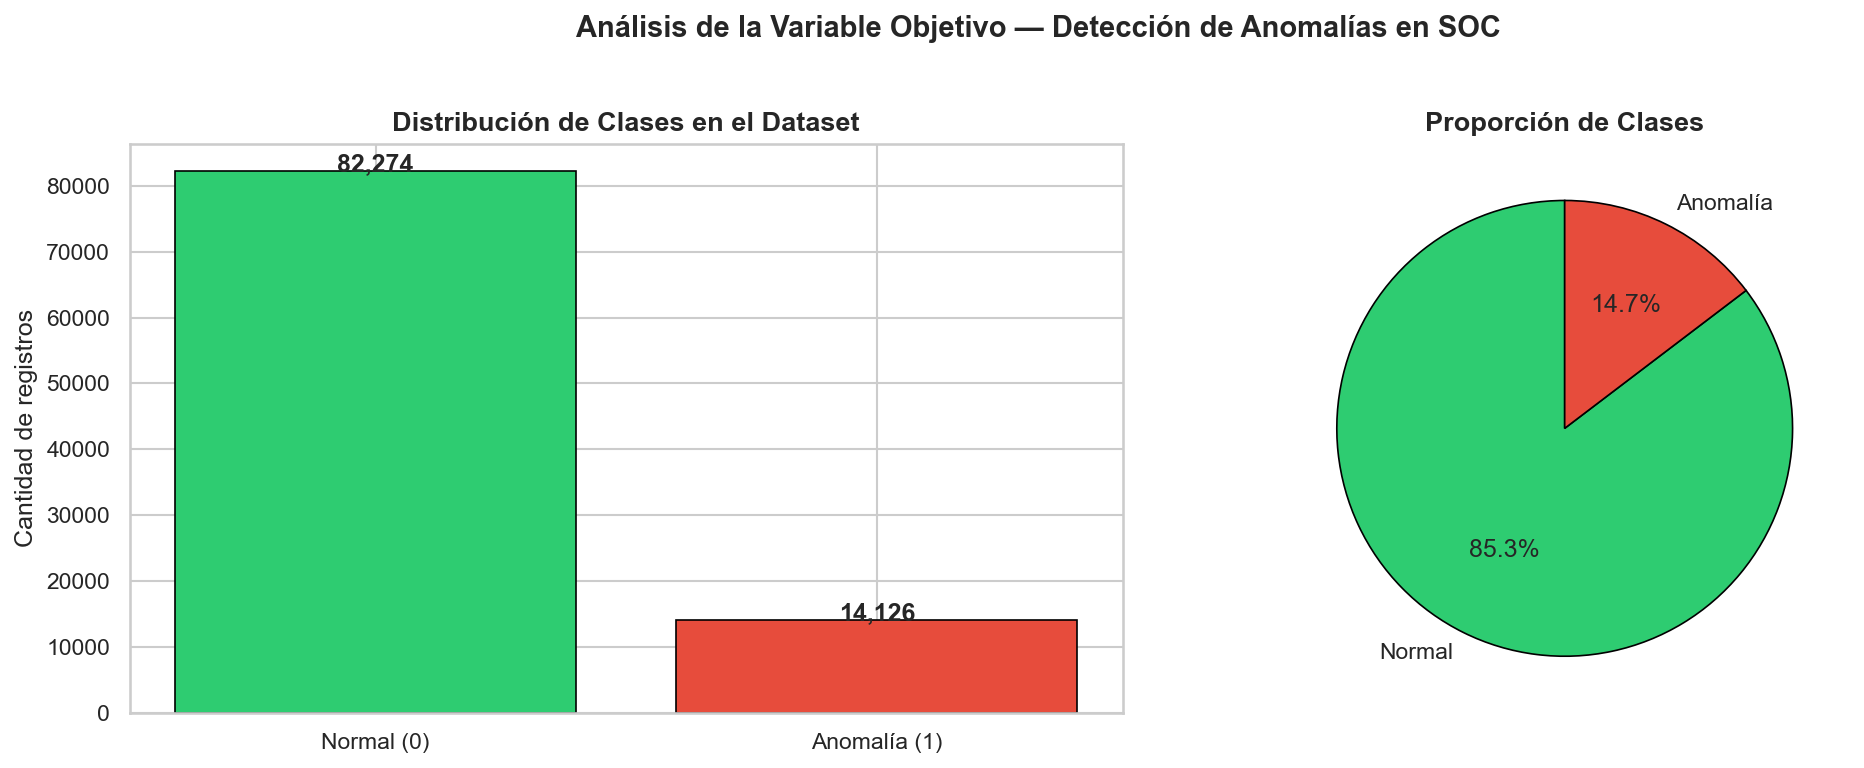

✅ Figura 1 guardada.


In [29]:
# ─── Gráfico 1: Distribución de clases ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
colores = ['#2ecc71', '#e74c3c']
conteo_plot = y.value_counts().sort_index()
axes[0].bar(['Normal (0)', 'Anomalía (1)'], conteo_plot.values, color=colores, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución de Clases en el Dataset', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(conteo_plot.values):
    axes[0].text(i, v + 5, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(conteo_plot.values, labels=['Normal', 'Anomalía'],
            autopct='%1.1f%%', colors=colores, startangle=90,
            wedgeprops={'edgecolor':'black', 'linewidth':0.8})
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Análisis de la Variable Objetivo — Detección de Anomalías en SOC',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribucion_clases.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figura 1 guardada.")

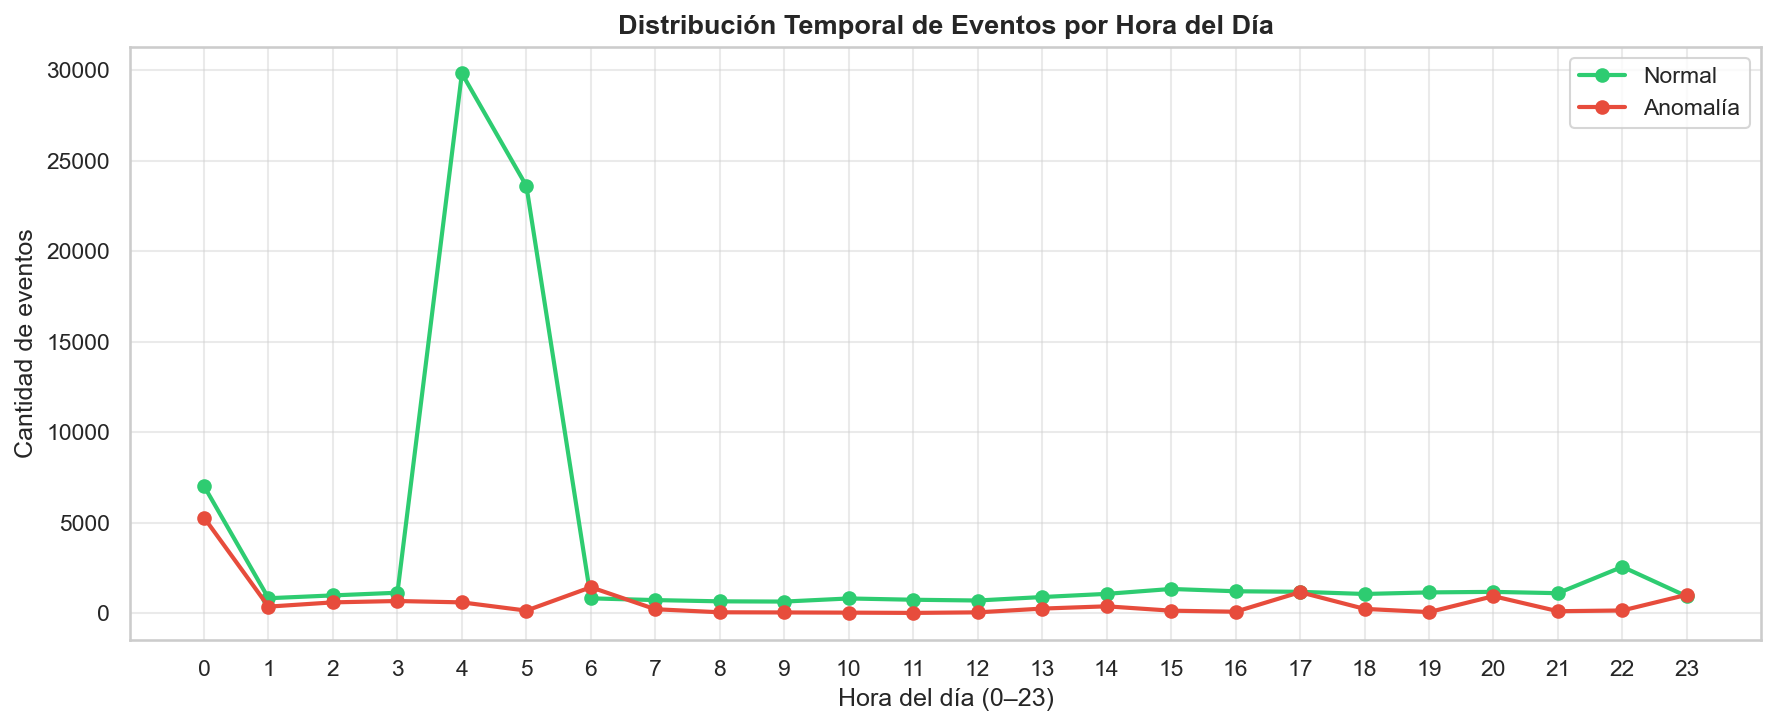

✅ Figura 2 guardada.


In [30]:
# ─── Gráfico 2: Eventos por hora del día ─────────────────────────────────────
if 'hora' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    for label_val, color, nombre in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Anomalía')]:
        subset = df[df['label'] == label_val]
        conteo_hora = subset['hora'].value_counts().sort_index()
        ax.plot(conteo_hora.index, conteo_hora.values, marker='o',
                label=nombre, color=color, linewidth=2)
    ax.set_title('Distribución Temporal de Eventos por Hora del Día', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hora del día (0–23)')
    ax.set_ylabel('Cantidad de eventos')
    ax.set_xticks(range(24))
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig('fig2_eventos_por_hora.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figura 2 guardada.")

In [34]:
# ─── Columnas que causan data leakage — EXCLUIR ──────────────────
EXCLUIR_LEAKAGE = [
    'level_enc',                  # usada para crear el label
    'contiene_keyword_anomalia',  # derivada directa del label
    'label'
]

features_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
features_numericas = [c for c in features_numericas 
                      if c not in EXCLUIR_LEAKAGE]

X = df[features_numericas].copy()
y = df['label'].copy()

# Eliminar varianza cero
cols_vz = X.columns[X.std() == 0].tolist()
X = X.drop(columns=cols_vz)

FEATURE_NAMES = X.columns.tolist()
print(f"✅ Features finales ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

✅ Features finales (3): ['hora', 'longitud_mensaje', 'fuente_enc']


---
## 🤖 FASE 3 — Entrenamiento del Modelo XGBoost

In [35]:
# ─── División Train / Test ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,       # 75% entrenamiento, 25% prueba
    random_state=42,
    stratify=y            # mantener proporción de clases
)

print(f"✅ División completada:")
print(f"   Train: {X_train.shape[0]:,} registros")
print(f"   Test : {X_test.shape[0]:,} registros")

# Balance en train
balance_train = y_train.value_counts(normalize=True) * 100
print(f"\n   Balance en Train — Normal: {balance_train.get(0,0):.1f}% | Anomalía: {balance_train.get(1,0):.1f}%")

✅ División completada:
   Train: 72,300 registros
   Test : 24,100 registros

   Balance en Train — Normal: 85.3% | Anomalía: 14.7%


In [36]:
# ─── Configuración y entrenamiento del modelo XGBoost ────────────────────────
# scale_pos_weight: corrige desbalance de clases
escala_peso = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1

modelo = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = escala_peso,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1
)

print("⏳ Entrenando modelo XGBoost...")
modelo.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print("\n✅ Modelo entrenado exitosamente.")

⏳ Entrenando modelo XGBoost...
[0]	validation_0-logloss:0.64083
[50]	validation_0-logloss:0.09364
[100]	validation_0-logloss:0.06864
[150]	validation_0-logloss:0.06296
[200]	validation_0-logloss:0.06043
[250]	validation_0-logloss:0.05920
[299]	validation_0-logloss:0.05833

✅ Modelo entrenado exitosamente.


---
## 📏 FASE 4 — Evaluación del Modelo

In [37]:
# ─── Predicciones ────────────────────────────────────────────────────────────
y_pred      = modelo.predict(X_test)
y_pred_prob = modelo.predict_proba(X_test)[:, 1]

# ─── Métricas ─────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
try:
    auc = roc_auc_score(y_test, y_pred_prob)
except:
    auc = float('nan')

print("="*50)
print("       REPORTE DE MÉTRICAS — XGBoost")
print("="*50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("="*50)
print("\n📋 Reporte completo por clase:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomalía']))

       REPORTE DE MÉTRICAS — XGBoost
  Accuracy  : 0.9807  (98.07%)
  Precision : 0.9034
  Recall    : 0.9720
  F1-Score  : 0.9364
  AUC-ROC   : 0.9952

📋 Reporte completo por clase:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     20569
    Anomalía       0.90      0.97      0.94      3531

    accuracy                           0.98     24100
   macro avg       0.95      0.98      0.96     24100
weighted avg       0.98      0.98      0.98     24100



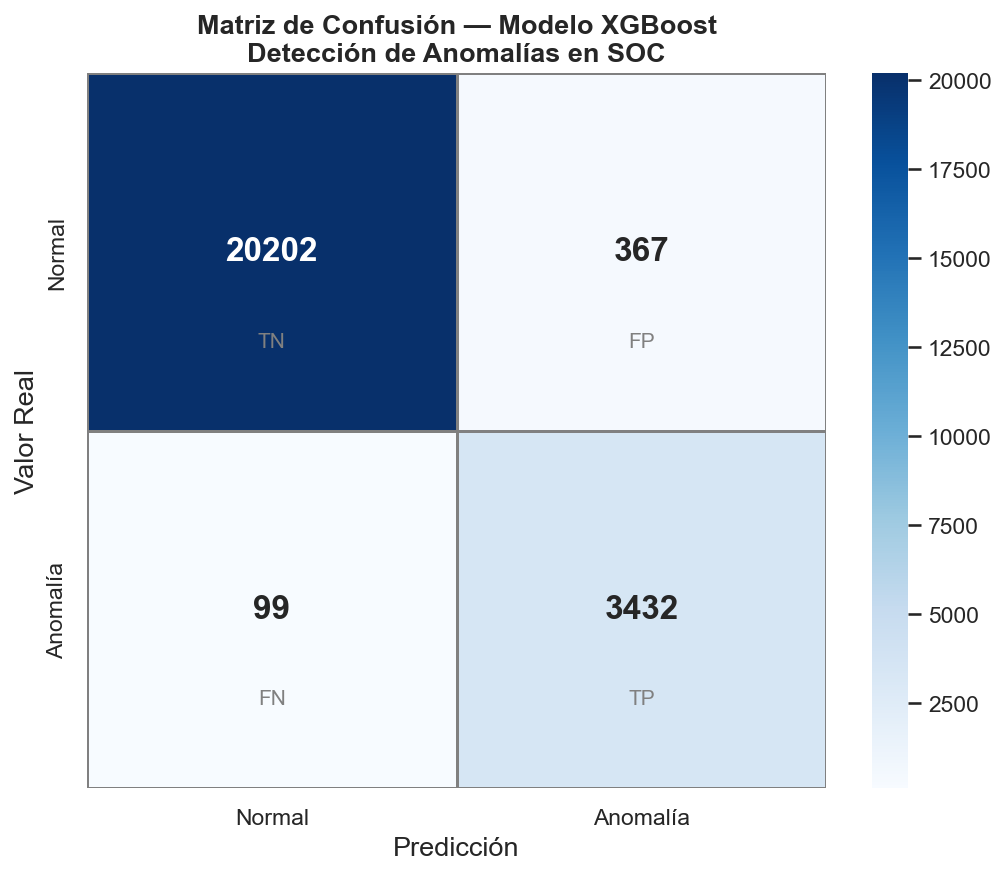

✅ Figura 3 guardada.


In [38]:
# ─── Gráfico 3: Matriz de Confusión ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'],
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_xlabel('Predicción', fontsize=13)
ax.set_ylabel('Valor Real', fontsize=13)
ax.set_title('Matriz de Confusión — Modelo XGBoost\nDetección de Anomalías en SOC',
             fontsize=13, fontweight='bold')

# Anotar TN, FP, FN, TP
etiquetas = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.75, etiquetas[i][j], ha='center',
                va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('fig3_matriz_confusion.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figura 3 guardada.")

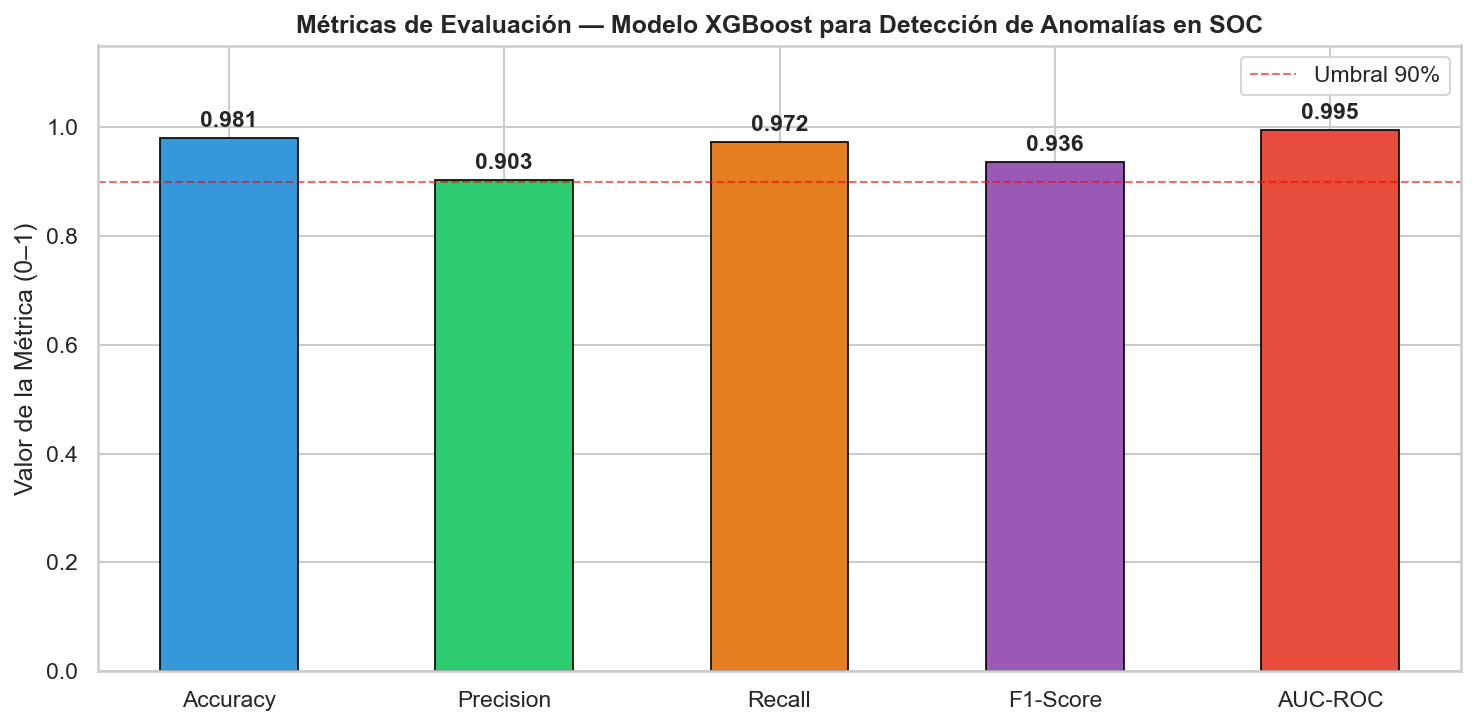

✅ Figura 4 guardada.


In [39]:
# ─── Gráfico 4: Métricas comparativas en barras ───────────────────────────────
metricas = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc}

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(metricas.keys(), metricas.values(),
                color=['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c'],
                edgecolor='black', linewidth=0.8, width=0.5)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.9, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Umbral 90%')
ax.set_title('Métricas de Evaluación — Modelo XGBoost para Detección de Anomalías en SOC',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor de la Métrica (0–1)')
ax.legend()
for barra, valor in zip(barras, metricas.values()):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.02,
            f'{valor:.3f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig4_metricas.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figura 4 guardada.")

---
## 🔍 FASE 5 — Explicabilidad XAI con SHAP y LIME

In [40]:
# ─── SHAP: Inicializar Explainer ──────────────────────────────────────────────
print("⏳ Calculando valores SHAP (puede tomar 1–2 minutos)...")
explainer_shap = shap.TreeExplainer(modelo)

# Usar muestra del test para rapidez (máx 500 registros)
N_SHAP = min(500, len(X_test))
X_shap = X_test.iloc[:N_SHAP]
shap_values = explainer_shap.shap_values(X_shap)

print(f"✅ Valores SHAP calculados para {N_SHAP} registros.")

⏳ Calculando valores SHAP (puede tomar 1–2 minutos)...
✅ Valores SHAP calculados para 500 registros.


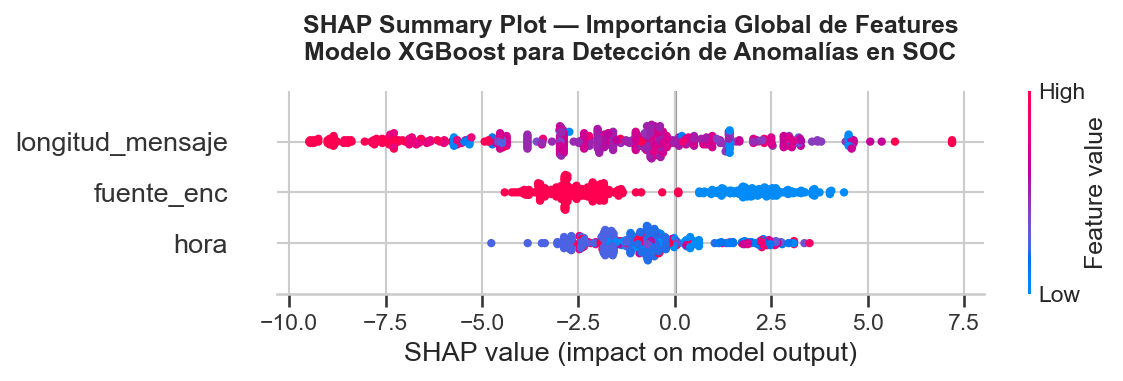

✅ Figura 5 (SHAP Summary Plot) guardada.


In [41]:
# ─── Gráfico 5: SHAP Summary Plot (Beeswarm) ─────────────────────────────────
plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — Importancia Global de Features\nModelo XGBoost para Detección de Anomalías en SOC',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig5_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figura 5 (SHAP Summary Plot) guardada.")

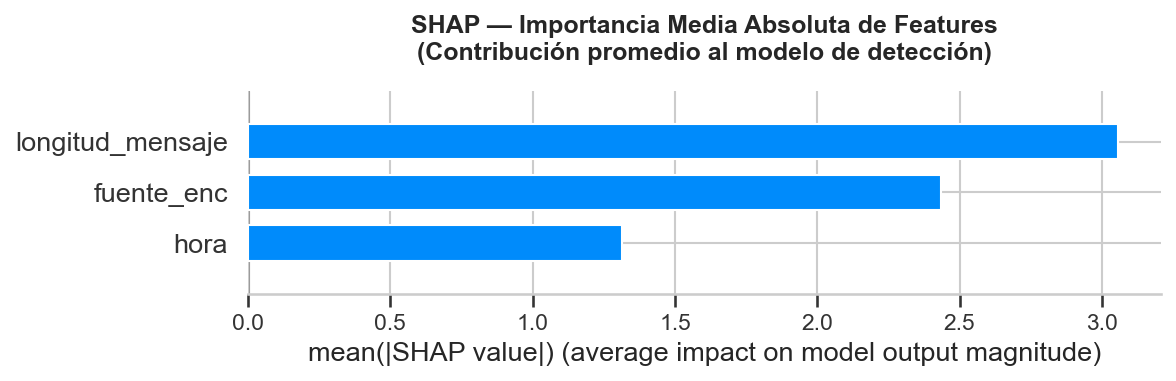

✅ Figura 6 (SHAP Bar Plot) guardada.


In [42]:
# ─── Gráfico 6: SHAP Bar Plot (importancia media absoluta) ───────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP — Importancia Media Absoluta de Features\n(Contribución promedio al modelo de detección)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig6_shap_barplot.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figura 6 (SHAP Bar Plot) guardada.")

🚨 Analizando alerta #3 del test set...
   Clase real     : Anomalía
   Clase predicha : Anomalía
   Probabilidad   : 0.9740


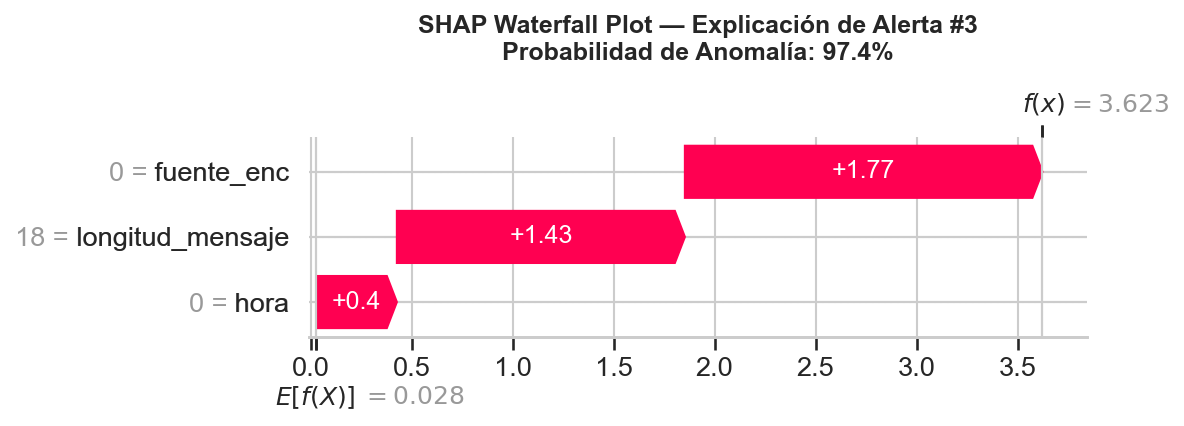

✅ Figura 7 (SHAP Waterfall) guardada.


In [43]:
# ─── Gráfico 7: SHAP Waterfall — explicación de UNA alerta específica ─────────
# Seleccionar la primera anomalía predicha del test set
indices_anomalias = np.where(y_pred == 1)[0]

if len(indices_anomalias) > 0:
    idx_alerta = indices_anomalias[0]   # primera anomalía detectada
    print(f"🚨 Analizando alerta #{idx_alerta} del test set...")
    print(f"   Clase real     : {'Anomalía' if y_test.iloc[idx_alerta]==1 else 'Normal'}")
    print(f"   Clase predicha : Anomalía")
    print(f"   Probabilidad   : {y_pred_prob[idx_alerta]:.4f}")

    explanation_waterfall = explainer_shap(X_shap.iloc[[idx_alerta]])

    plt.figure(figsize=(11, 7))
    shap.waterfall_plot(explanation_waterfall[0], max_display=12, show=False)
    plt.title(f'SHAP Waterfall Plot — Explicación de Alerta #{idx_alerta}\n'
              f'Probabilidad de Anomalía: {y_pred_prob[idx_alerta]*100:.1f}%',
              fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('fig7_shap_waterfall.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figura 7 (SHAP Waterfall) guardada.")
else:
    print("⚠️ No se detectaron anomalías en el test set para el waterfall plot.")

In [44]:
# ─── LIME: Explicación local de una alerta ────────────────────────────────────
print("⏳ Inicializando explicador LIME...")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train.values,
    feature_names   = FEATURE_NAMES,
    class_names     = ['Normal', 'Anomalía'],
    mode            = 'classification',
    discretize_continuous = True,
    random_state    = 42
)

# Seleccionar la misma alerta analizada con SHAP
if len(indices_anomalias) > 0:
    instancia_lime = X_test.values[idx_alerta]

    explicacion_lime = explainer_lime.explain_instance(
        data_row       = instancia_lime,
        predict_fn     = modelo.predict_proba,
        num_features   = 12,
        num_samples    = 1000
    )

    print(f"✅ Explicación LIME generada para la alerta #{idx_alerta}")
    print(f"\n📋 Contribución de features (LIME):")
    for feat, peso in explicacion_lime.as_list():
        signo = '🔴 +' if peso > 0 else '🟢'
        print(f"   {signo}{peso:+.4f}  →  {feat}")

⏳ Inicializando explicador LIME...
✅ Explicación LIME generada para la alerta #3

📋 Contribución de features (LIME):
   🔴 ++0.5039  →  fuente_enc <= 0.00
   🔴 ++0.1846  →  hora <= 4.00
   🟢-0.1291  →  longitud_mensaje <= 86.00


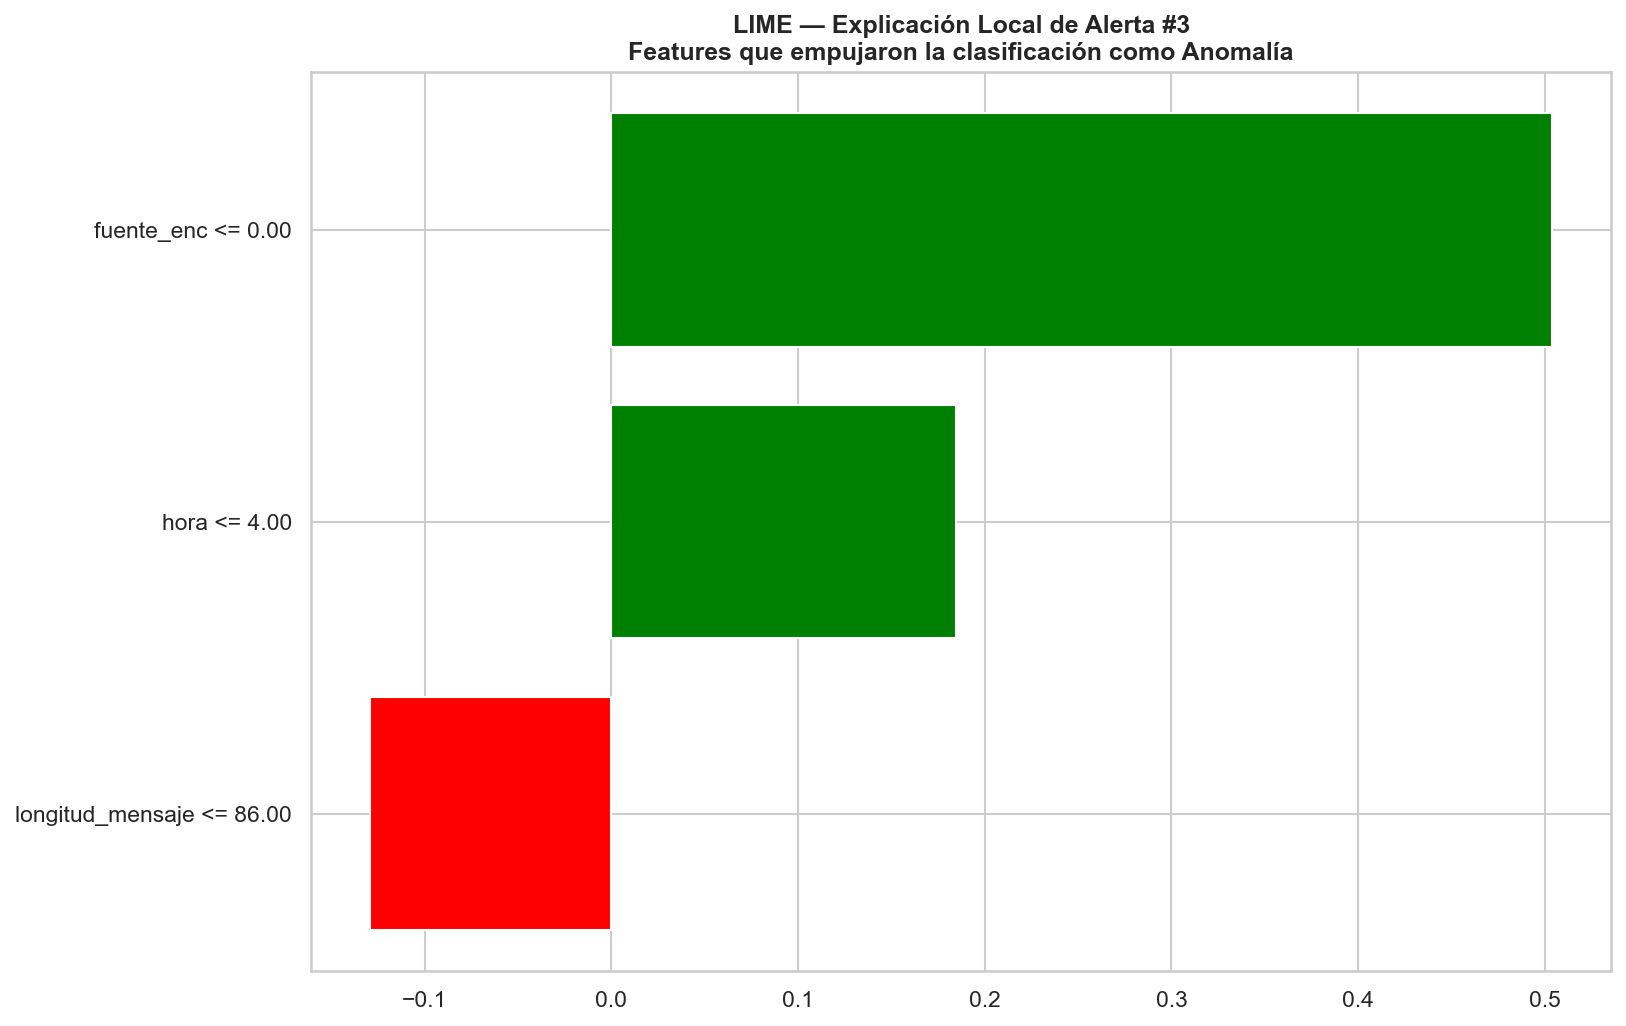

✅ Figura 8 (LIME) guardada.


In [45]:
# ─── Gráfico 8: LIME — visualización como figura matplotlib ──────────────────
if len(indices_anomalias) > 0:
    fig_lime = explicacion_lime.as_pyplot_figure()
    fig_lime.set_size_inches(11, 7)
    plt.title(f'LIME — Explicación Local de Alerta #{idx_alerta}\n'
              f'Features que empujaron la clasificación como Anomalía',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig8_lime_explicacion.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figura 8 (LIME) guardada.")

---
## 📋 Resumen Final del Experimento

In [46]:
print("="*60)
print("   RESUMEN DEL EXPERIMENTO")
print("   Integración de SHAP y LIME en SOC")
print("="*60)
print(f"\n📂 Dataset utilizado:")
print(f"   - logserver.tar.gz (registros del sistema/servidor)")
print(f"   - logsapp.tar.gz   (registros de aplicación)")
print(f"   - Total registros  : {len(df):,}")
print(f"   - Features usados  : {len(FEATURE_NAMES)}")
print(f"\n🤖 Modelo: XGBoost (n_estimators=300, max_depth=6, lr=0.1)")
print(f"   - Train set        : {len(X_train):,} registros")
print(f"   - Test set         : {len(X_test):,} registros")
print(f"\n📏 Métricas de Evaluación:")
print(f"   - Accuracy         : {acc:.4f}")
print(f"   - Precision        : {prec:.4f}")
print(f"   - Recall           : {rec:.4f}")
print(f"   - F1-Score         : {f1:.4f}")
print(f"   - AUC-ROC          : {auc:.4f}")
print(f"\n🔍 Explicabilidad XAI aplicada:")
print(f"   - SHAP Summary Plot  (importancia global de features)")
print(f"   - SHAP Bar Plot      (ranking de features)")
print(f"   - SHAP Waterfall     (explicación de alerta específica)")
print(f"   - LIME Tabular       (explicación local de alerta)")
print(f"\n📊 Figuras generadas:")
figuras = ['fig1_distribucion_clases.png', 'fig2_eventos_por_hora.png',
           'fig3_matriz_confusion.png', 'fig4_metricas.png',
           'fig5_shap_summary.png', 'fig6_shap_barplot.png',
           'fig7_shap_waterfall.png', 'fig8_lime_explicacion.png']
for fig_name in figuras:
    existe = '✅' if os.path.exists(fig_name) else '⚠️ (pendiente)'
    print(f"   {existe} {fig_name}")
print("="*60)

   RESUMEN DEL EXPERIMENTO
   Integración de SHAP y LIME en SOC

📂 Dataset utilizado:
   - logserver.tar.gz (registros del sistema/servidor)
   - logsapp.tar.gz   (registros de aplicación)
   - Total registros  : 96,400
   - Features usados  : 3

🤖 Modelo: XGBoost (n_estimators=300, max_depth=6, lr=0.1)
   - Train set        : 72,300 registros
   - Test set         : 24,100 registros

📏 Métricas de Evaluación:
   - Accuracy         : 0.9807
   - Precision        : 0.9034
   - Recall           : 0.9720
   - F1-Score         : 0.9364
   - AUC-ROC          : 0.9952

🔍 Explicabilidad XAI aplicada:
   - SHAP Summary Plot  (importancia global de features)
   - SHAP Bar Plot      (ranking de features)
   - SHAP Waterfall     (explicación de alerta específica)
   - LIME Tabular       (explicación local de alerta)

📊 Figuras generadas:
   ✅ fig1_distribucion_clases.png
   ✅ fig2_eventos_por_hora.png
   ✅ fig3_matriz_confusion.png
   ✅ fig4_metricas.png
   ✅ fig5_shap_summary.png
   ✅ fig6_shap_